In [8]:
import pandas as pd

cols = ["unit", "cycle", "set1", "set2", "set3"] + [f"s{i}" for i in range(1, 22)]
train = pd.read_csv("../data/train_FD001.txt", sep=r"\s+", header=None, names=cols)
test = pd.read_csv("../data/test_FD001.txt", sep=r"\s+", header=None, names=cols)
rul_test = pd.read_csv("../data/RUL_FD001.txt", header=None, names=["RUL"])

print(train.shape, test.shape, rul_test.shape)

(20631, 26) (13096, 26) (100, 1)


In [9]:
train.head()

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
train["RUL"] = train.groupby("unit")["cycle"].transform("max") - train["cycle"]
train["RUL"] = train["RUL"].clip(upper=125)
train[["unit", "cycle", "RUL"]].head(10)

,unit,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [11]:
constant = [c for c in train.columns if train[c].std() < 1e-4]
print(constant)
train = train.drop(columns=constant)
test = test.drop(columns=constant)

['set3', 's1', 's5', 's10', 's16', 's18', 's19']


C:\Users\hamna\AppData\Local\Temp\ipykernel_8484\3347810383.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.flat[0].legend()


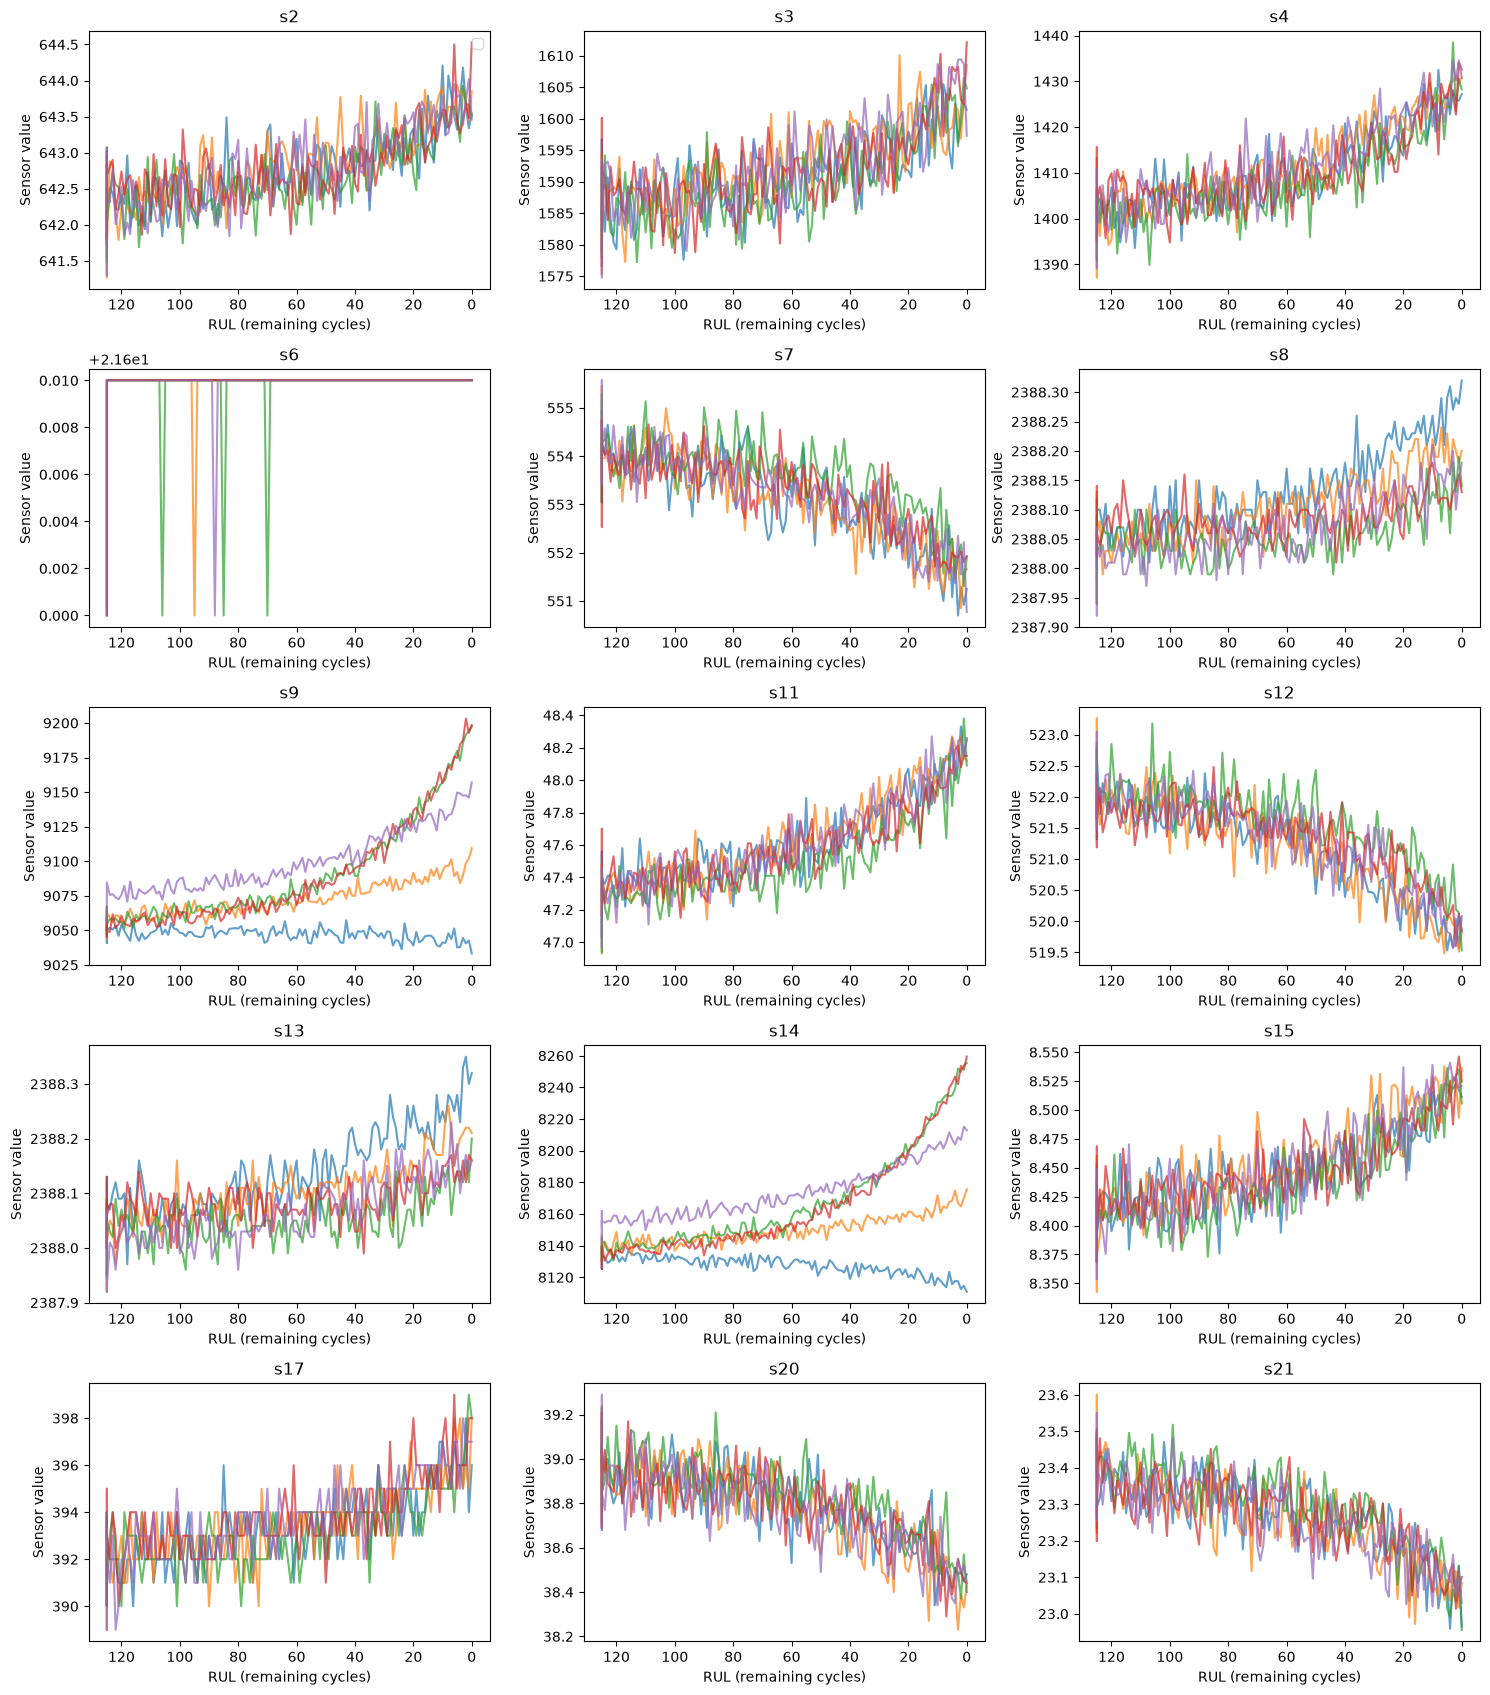

In [ ]:
import matplotlib.pyplot as plt

sensors = [c for c in train.columns if c.startswith("s") and not c.startswith("set")]
fig, axes = plt.subplots(len(sensors) // 3 + 1, 3, figsize=(15, 20))
for ax, s in zip(axes.flat, sensors):
    for u in [1, 2, 3, 4, 5]:
        d = train[train["unit"] == u]
        ax.plot(d["RUL"], d[s], alpha=0.7, label=f"Engine {u}")
    ax.set_title(s)
    ax.set_xlabel("RUL (remaining cycles)")
    ax.set_ylabel("Sensor value")
    ax.invert_xaxis()

for ax in axes.flat[len(sensors):]:
    ax.set_visible(False)

axes.flat[0].legend()
plt.tight_layout()

In [13]:
train.corr()["RUL"].drop(["RUL", "unit", "cycle"]).sort_values()

s11    -0.775230
s4     -0.757157
s15    -0.720858
s17    -0.680829
s2     -0.678458
s3     -0.655030
s8     -0.624568
s13    -0.624034
s9     -0.462151
s14    -0.369753
s6     -0.108289
set2   -0.007091
set1   -0.005556
s20     0.704626
s21     0.707334
s7      0.733021
s12     0.748870
Name: RUL, dtype: float64